# M16 — Teacher-Student Knowledge Distillation

> **Chunk F (Generalization & Compression)**  
> **Model ID:** `M16` | **Member:** B  
> **Protocol Compliance:** Real ICBHI Audio, Zero Patient Leakage, Protocol §4 Schema Compliant.

---

### 📌 Overview
This notebook implements **Teacher-Student Knowledge Distillation (KD)** to compress the 4.15M parameter **M17 Stage-2 Prototypical Model** into a lightweight **Student 2D-CNN** (~0.46M parameters, **9.0× parameter reduction**).

---

### 🎯 Key Deliverables
1. **Teacher-Student Distillation Loss**: Combined Cross-Entropy and KL-Divergence soft-label loss ($T=3.0, \alpha=0.7$).
2. **Real Audio Training**: Trains student model on real ICBHI audio using §2 team audio parameters.
3. **Compression Metric Audit**: Computes parameter reduction ratio and model size savings (MB).
4. **Loss Curve Visualizations**: Saves training and distillation loss curves to `Distillation_Loss_Curve.png`.
5. **Protocol Export**: Outputs `results_M16.json` matching Protocol §4 schema.

---

> **2026-08-29 — re-run required (`SYNTHETIC_DATA_REMEDIATION.md` item 4).** The
> previous result was not a held-out score. `discover_icbhi_distill_files` indexed
> **one row per `.wav`** — 851 whole recordings, each tiled to 8 s and labelled with
> its patient's diagnosis — and the student was distilled over those rows and then
> scored on the same rows; there was **no train/test split in the notebook at all**,
> so `student_accuracy = 0.9318` is a training-set number on a corpus where COPD
> dominates. The teacher was loaded with `strict=False` inside a `try/except` that
> only printed a note, so a mismatched checkpoint left a **randomly initialised
> teacher** to distil from.
>
> Sections 3–7 are rewritten: cycle-level index on the corrected
> patient-independent official split, teacher must load fully or the notebook
> raises, distillation on TRAIN only, student scored every epoch on the untouched
> TEST split, best epoch by **macro-F1** (accuracy rewards the majority-class
> collapse distillation tends to produce), exported with `confusion_matrix_raw` and
> retention against the teacher's own TEST score.
> **Correction, later on 2026-08-29.** The head-width guard added above fired on the first
> re-run: *"teacher head has 256 outputs but CFG['disease_classes'] declares 4"*. That 256 is
> M17's `proto_embed_dim`, and it settles the question the old `strict=False` was hiding —
> **M17 v2 is a prototypical network and its checkpoint contains only the projection MLP.**
> There is no backbone and no classifier head in that file, so the previous code was matching
> *nothing* and distilling from a fully random teacher. Section 4 now assembles the real
> teacher — M2 backbone → M17 projection → negative squared distance to class prototypes
> computed on TRAIN — which needs the **M2 checkpoint attached as well as M17's**.



In [4]:
# ============================================================
# Section 1: Setup & Dependencies
# ============================================================
import os
import sys
import math
import glob
import json
import re
import random
import zipfile
import io
import shutil
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Device:  {DEVICE} ({GPU_NAME})')
print(f'PyTorch: {torch.__version__}')


Device:  cuda (Tesla T4)
PyTorch: 2.10.0+cu128


In [5]:
# ============================================================
# Section 2: Configuration & Path Resolution
# ============================================================

if os.path.exists('/kaggle'):
    PLATFORM = 'Kaggle'
    BASE_DIR = '/kaggle/working'
elif os.path.exists('/content'):
    PLATFORM = 'Colab'
    BASE_DIR = '/content'
else:
    PLATFORM = 'Local'
    BASE_DIR = '.'

print(f'Platform: {PLATFORM}')

DRIVE_DIR = None
if PLATFORM == 'Colab':
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
        DRIVE_DIR = '/content/drive/MyDrive/OWMTL/M16'
        os.makedirs(DRIVE_DIR, exist_ok=True)
        print(f'Drive Backup Path: {DRIVE_DIR}')
    except Exception as e:
        print(f'Drive mount skipped ({e})')

def resolve_checkpoint(candidates):
    return next((p for p in candidates if p and os.path.exists(p)), None)

M17_CKPT_PATH = resolve_checkpoint([
    '/content/M17_best_model.pth',
    '/kaggle/input/m17-checkpoint/best_model.pth',
    '/kaggle/input/datasets/barshonbasak/m17-checkpoint/best_model.pth',
    '/content/drive/MyDrive/OWMTL/M17/best_model.pth',
    '../M17/best_model.pth',
    os.path.join(BASE_DIR, 'results_M17', 'best_model.pth'),
])
if M17_CKPT_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if ('m17' in f.lower() or 'm17' in root.lower()) and (f.endswith('.pth') or f.endswith('.zip')):
                M17_CKPT_PATH = os.path.join(root, f)
                break
        if M17_CKPT_PATH: break

M2_CKPT_PATH = resolve_checkpoint([
    '/content/M2_best_model.pth',
    '/kaggle/input/m2-checkpoint/best_model.pth',
    '/kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth',
    '/content/drive/MyDrive/OWMTL/M2/best_model.pth',
    '../M2/best_model.pth',
    os.path.join(BASE_DIR, 'results_M2', 'best_model.pth'),
])
if M2_CKPT_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            if ('m2' in f.lower() or 'm2' in root.lower()) and f.endswith(('.pth', '.zip')):
                M2_CKPT_PATH = os.path.join(root, f)
                break
        if M2_CKPT_PATH:
            break

ICBHI_ROOTS = [
    '/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    '/kaggle/input/respiratory-sound-database/audio_and_txt_files',
    '/content/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files',
    './data/audio_and_txt_files',
]
ICBHI_PATH = next((p for p in ICBHI_ROOTS if os.path.exists(p)), None)
if ICBHI_PATH is None and os.path.exists('/kaggle/input'):
    for root, dirs, files in os.walk('/kaggle/input'):
        if any(f.endswith('.wav') for f in files) and any(f.endswith('.txt') for f in files):
            ICBHI_PATH = root
            break

CFG = {
    'model_id': 'M16',
    'model_name': 'Teacher-Student Knowledge Distillation',
    'member': 'B',
    'seed': SEED,

    # Shared Audio Parameters (§2)
    'sample_rate': 16000,
    'duration_s': 8.0,
    'n_mels': 128,
    'n_fft': 1024,
    'hop_length': 160,
    'win_length': 400,
    'f_min': 50,
    'f_max': 2000,
    'n_samples': int(16000 * 8.0),
    'n_frames': 1 + math.floor(128000 / 160),

    # Distillation Parameters
    'temperature': 3.0,
    'alpha': 0.7,
    'epochs': 10,
    'lr': 1e-3,
    'batch_size': 32,
    # REVIEW (2026-08-29): this notebook declared 3 known_classes but instantiated
    # a 4-output head and loaded the M17 checkpoint with strict=False, so the
    # label space was never pinned down. M17 v2's stage-2 space is the 4 below.
    # Section 4 now asserts the checkpoint's head width matches this list and
    # raises if it does not -- if your checkpoint is the 3-class stage-0 head,
    # shorten this list to ['COPD', 'Healthy', 'URTI'].
    'disease_classes': ['COPD', 'Healthy', 'URTI', 'Pneumonia'],

    # M17 v2 is a PROTOTYPICAL network: its checkpoint holds only the projection
    # MLP, so the teacher is assembled as M2 backbone -> M17 projection ->
    # distance to prototypes. These four values must match M17 v2's own config
    # (results_M17.json -> config) or the state dicts will not fit.
    'm2_depth': 5,
    'm2_base_width': 48,
    'proto_embed_dim': 256,
    'proto_temperature': 0.1,
    'known_classes': ['COPD', 'Healthy', 'URTI'],

    'm2_ckpt_path': M2_CKPT_PATH,
    'm17_ckpt_path': M17_CKPT_PATH,
    'icbhi_path': ICBHI_PATH,
    'results_dir': os.path.join(BASE_DIR, 'results_M16'),
}
os.makedirs(CFG['results_dir'], exist_ok=True)

print(f"\n{'='*60}")
print('M16 CONFIGURATION — Knowledge Distillation')
print(f"{'='*60}")
print(f"  M2  Backbone Checkpoint: {CFG['m2_ckpt_path'] or 'NOT FOUND'}")
print(f"  M17 Projection Checkpoint: {CFG['m17_ckpt_path'] or 'NOT FOUND'}")
print(f"  ICBHI Path:             {CFG['icbhi_path'] or 'NOT FOUND'}")
print(f"{'='*60}")


Platform: Kaggle

M16 CONFIGURATION — Knowledge Distillation
  M2  Backbone Checkpoint: /kaggle/input/datasets/barshonbasak/m2-checkpoint/best_model.pth
  M17 Projection Checkpoint: /kaggle/input/datasets/barshonbasak/m17-checkpoints/best_model.pth
  ICBHI Path:             /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files


In [6]:
# ============================================================
# Section 3: Corrected Split, Cycle Index, Loaders, Metrics
# ============================================================
# Rewritten 2026-08-29 (SYNTHETIC_DATA_REMEDIATION.md item 4). The previous
# version indexed ONE row per .wav -- 851 whole recordings, each tiled to 8 s and
# given its patient's diagnosis as a single label -- and used the SAME rows for
# fitting and for reporting. There was no train/test split anywhere in the
# notebook, so the headline number was a training-set score on 851 recordings
# whose class balance is dominated by COPD.
#
# This version: every annotated respiratory cycle with its own start/end, disease
# label from patient_diagnosis.csv, on the corrected patient-independent official
# split. Nothing is fitted on a row that is later scored.

from torch.utils.data import Dataset, DataLoader   # M18's Section 1 does not import these

# ---- locate the official split file (raises rather than falling back) -------
SPLIT_NAMES = ['ICBHI_challenge_train_test.txt', 'icbhi_challenge_train_test.txt']


def find_split_file():
    roots = ['/kaggle/input', '/content', '.', '..',
             os.path.dirname(CFG['icbhi_path'] or '.')]
    for root in roots:
        if not root or not os.path.isdir(root):
            continue
        for dirpath, _, files in os.walk(root):
            for name in SPLIT_NAMES:
                if name in files:
                    return os.path.join(dirpath, name)
    return None


def find_diagnosis_file():
    names = ['patient_diagnosis.csv', 'ICBHI_Challenge_diagnosis.txt', 'patient_diagnosis.txt']
    curr = CFG['icbhi_path']
    for _ in range(4):
        for n in names:
            c = os.path.join(curr, n)
            if os.path.exists(c):
                return c
        parent = os.path.dirname(curr)
        if parent == curr:
            break
        curr = parent
    if os.path.exists('/kaggle/input'):
        for root, _, files in os.walk('/kaggle/input'):
            for n in names:
                if n in files:
                    return os.path.join(root, n)
    return None


if not CFG['icbhi_path']:
    raise FileNotFoundError('ICBHI audio directory not found. Refusing to run.')

SPLIT_FILE = find_split_file()
if SPLIT_FILE is None:
    raise FileNotFoundError(
        'ICBHI_challenge_train_test.txt not found. The repo copy is at '
        "Asif's/ICBHI_challenge_train_test.txt -- attach it as a Kaggle dataset. "
        'Refusing to run: an invented split is not a split '
        '(Model_Training_Protocol.md section 1).')

DIAG_FILE = find_diagnosis_file()
if DIAG_FILE is None:
    raise FileNotFoundError(
        f'patient diagnosis file not found near {CFG["icbhi_path"]}. '
        'Refusing to run: fabricated labels are not a fallback '
        '(Model_Training_Protocol.md section 1.2).')
print(f'Split file:     {SPLIT_FILE}')
print(f'Diagnosis file: {DIAG_FILE}')

# ---- corrected split, verified against the published counts ----------------
OFFICIAL_RECORDINGS, OFFICIAL_TRAIN, OFFICIAL_TEST = 920, 539, 381
OFFICIAL_PATIENTS, OFFICIAL_OVERLAP = 126, {156, 218}
CORRECTED_TRAIN, CORRECTED_TEST = 551, 369


def pid_of(stem):
    return int(stem.split('_')[0])


split_map = {}
with open(SPLIT_FILE) as fh:
    for line in fh:
        t = line.replace('\t', ' ').replace(',', ' ').split()
        if len(t) >= 2 and t[1].lower() in ('train', 'test'):
            split_map[t[0].replace('.wav', '')] = t[1].lower()

sides = {}
for s, v in split_map.items():
    sides.setdefault(pid_of(s), set()).add(v)
overlap = {p for p, v in sides.items() if len(v) > 1}
n_tr = sum(1 for v in split_map.values() if v == 'train')
assert len(split_map) == OFFICIAL_RECORDINGS, f'{len(split_map)} recordings != 920'
assert n_tr == OFFICIAL_TRAIN and len(split_map) - n_tr == OFFICIAL_TEST
assert len({pid_of(s) for s in split_map}) == OFFICIAL_PATIENTS
assert overlap == OFFICIAL_OVERLAP, f'overlap {sorted(overlap)} != {sorted(OFFICIAL_OVERLAP)}'
corrected = {s: ('train' if pid_of(s) in overlap else v) for s, v in split_map.items()}
c_te = sum(1 for v in corrected.values() if v == 'test')
assert len(corrected) - c_te == CORRECTED_TRAIN and c_te == CORRECTED_TEST
print(f'[OK] corrected split: {CORRECTED_TRAIN} train / {CORRECTED_TEST} test recordings, '
      f'patient-independent.')

# ---- diagnosis map (no fallback) -------------------------------------------
diag_map = {}
with open(DIAG_FILE, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        parts = [p.strip() for p in re.split(r'[,;\t\s]+', line.strip()) if p.strip()]
        if len(parts) >= 2:
            try:
                diag_map[int(parts[0])] = parts[1]
            except ValueError:
                continue
if len(diag_map) != OFFICIAL_PATIENTS:
    raise ValueError(f'diagnosis map has {len(diag_map)} entries, expected {OFFICIAL_PATIENTS}. '
                     f'Refusing to run on a partial label set.')
print(f'[OK] diagnosis map: {len(diag_map)} patients.')

CLASS_TO_IDX = {c: i for i, c in enumerate(CFG['disease_classes'])}

# ---- cycle-level index -----------------------------------------------------
rows, n_missing, n_unlisted, n_other_class = [], 0, 0, 0
for wav in sorted(glob.glob(os.path.join(CFG['icbhi_path'], '**', '*.wav'), recursive=True)):
    stem = os.path.splitext(os.path.basename(wav))[0]
    txt = os.path.splitext(wav)[0] + '.txt'
    if not os.path.exists(txt):
        n_missing += 1
        continue
    sp = corrected.get(stem)
    if sp is None:
        n_unlisted += 1
        continue
    dis = diag_map.get(pid_of(stem))
    if dis not in CLASS_TO_IDX:
        n_other_class += 1
        continue
    with open(txt, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            p = line.split()
            if len(p) < 4:
                continue
            start, end = float(p[0]), float(p[1])
            if end <= start:
                continue
            rows.append({'path': wav, 'stem': stem, 'patient_id': pid_of(stem),
                         'start': start, 'end': end,
                         'label': CLASS_TO_IDX[dis], 'diagnosis': dis, 'split': sp})

df_all = pd.DataFrame(rows)
assert len(df_all) > 3000, f'only {len(df_all)} cycles indexed -- check the audio directory'
if n_missing:
    print(f'skipped {n_missing} recordings with no annotation .txt')
if n_unlisted:
    print(f'skipped {n_unlisted} recordings absent from the split file')
if n_other_class:
    print(f'skipped {n_other_class} recordings outside {CFG["disease_classes"]}')

df_train = df_all[df_all.split == 'train'].reset_index(drop=True)
df_test = df_all[df_all.split == 'test'].reset_index(drop=True)
assert not (set(df_train.patient_id) & set(df_test.patient_id)), 'patient leakage'
print(f'Cycles: {len(df_train)} train / {len(df_test)} test '
      f'({df_train.patient_id.nunique()} / {df_test.patient_id.nunique()} patients), 0% leakage.')
print(df_all.groupby(['split', 'diagnosis']).size().to_string())


def extract_log_mel(wav_path, start, end, cfg):
    sr, n_samples = cfg['sample_rate'], cfg['n_samples']
    try:
        audio, _ = librosa.load(wav_path, sr=sr, offset=start,
                                duration=max(end - start, 0.05), mono=True)
    except Exception as e:
        raise RuntimeError(f'failed to load audio: {wav_path} [{start}, {end}]') from e
    if len(audio) == 0:
        raise RuntimeError(f'empty audio decoded from {wav_path} [{start}, {end}]')
    if len(audio) < n_samples:
        audio = np.tile(audio, math.ceil(n_samples / len(audio)))[:n_samples]
    else:
        audio = audio[:n_samples]
    mel = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=cfg['n_mels'], n_fft=cfg['n_fft'],
        hop_length=cfg['hop_length'], win_length=cfg['win_length'],
        fmin=cfg['f_min'], fmax=cfg['f_max'], power=2.0)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    T = log_mel.shape[1]
    if T < cfg['n_frames']:
        log_mel = np.pad(log_mel, ((0, 0), (0, cfg['n_frames'] - T)), mode='constant')
    return log_mel[:, :cfg['n_frames']][np.newaxis, :, :].astype(np.float32)


class ICBHI_CycleDataset(Dataset):
    def __init__(self, df, cfg):
        self.records = df.to_dict('records')
        self.cfg = cfg

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        return (torch.from_numpy(extract_log_mel(r['path'], r['start'], r['end'], self.cfg)),
                torch.tensor(r['label'], dtype=torch.long))


loader_train = DataLoader(ICBHI_CycleDataset(df_train, CFG),
                          batch_size=CFG['batch_size'], shuffle=True)
loader_test = DataLoader(ICBHI_CycleDataset(df_test, CFG),
                         batch_size=CFG['batch_size'], shuffle=False)

CFG['split_method'] = 'official_60_40_patient_independent_corrected'
CFG['split_file'] = SPLIT_FILE
CFG['num_classes'] = len(CFG['disease_classes'])


# ---- metrics ---------------------------------------------------------------
def full_metrics(y_true, y_pred, class_names):
    # imported locally so this block drops into any of the M16/M18/M20
    # notebooks unchanged, whatever their Section 1 imports happen to be
    from sklearn.metrics import (accuracy_score, confusion_matrix,
                                 precision_recall_fscore_support)
    n_cls = len(class_names)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_cls)))
    p, r, f, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(n_cls)), zero_division=0)
    spec = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i].sum() - tp
        tn = cm.sum() - tp - fp - fn
        spec.append(tn / (tn + fp) if (tn + fp) else 0.0)
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_macro': float(p.mean()), 'recall_macro': float(r.mean()),
        'f1_macro': float(f.mean()), 'specificity_macro': float(np.mean(spec)),
        'majority_class_rate': float(np.bincount(y_true, minlength=n_cls).max() / len(y_true)),
        'per_class': {class_names[i]: {
            'precision': round(float(p[i]), 4), 'recall': round(float(r[i]), 4),
            'f1': round(float(f[i]), 4), 'specificity': round(float(spec[i]), 4),
            'support': int(sup[i])} for i in range(n_cls)},
        'confusion_matrix_raw': cm.tolist(),
        'confusion_matrix_normalized': np.round(
            cm / np.maximum(cm.sum(1, keepdims=True), 1), 4).tolist(),
    }

Split file:     /kaggle/input/datasets/sudamchandrabasak/icbhi-challenge-train-test-split/ICBHI_challenge_train_test.txt
Diagnosis file: /kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv
[OK] corrected split: 551 train / 369 test recordings, patient-independent.
[OK] diagnosis map: 126 patients.
skipped 1 recordings absent from the split file
skipped 32 recordings outside ['COPD', 'Healthy', 'URTI', 'Pneumonia']
Cycles: 4049 train / 2536 test (67 / 43 patients), 0% leakage.
split  diagnosis
test   COPD         2289
       Healthy       175
       URTI           72
train  COPD         3457
       Healthy       147
       Pneumonia     274
       URTI          171


In [7]:
# ============================================================
# Section 4: Prototypical Teacher & Student  (teacher must load, or raise)
# ============================================================
# Corrected 2026-08-29 after the head-width guard fired with
# "teacher head has 256 outputs but CFG['disease_classes'] declares 4".
#
# That 256 is M17's `proto_embed_dim`, and it is the whole story: M17 v2 is a
# PROTOTYPICAL network. Its checkpoint holds ONLY `proto_head_stage2.state_dict()`
# -- the projection MLP (embedding_dim -> 512 -> 256). There is no backbone in it
# and no classifier head anywhere; its four logits are NEGATIVE SQUARED DISTANCES
# to four class prototypes computed from the support set at inference time.
#
# So a 4-logit teacher cannot be loaded from that file, and the old
# `load_state_dict(..., strict=False)` inside a try/except was not "mostly
# working" -- it matched nothing and distilled from a randomly initialised net.
# The teacher is assembled from its three real parts instead:
#
#     M2 backbone (frozen)  ->  M17 projection  ->  distance to prototypes
#
# Prototypes are computed on TRAIN only, so no test cycle informs the teacher.

import torch.nn.functional as F   # M18's Section 1 does not import this


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=pool),
        )

    def forward(self, x):
        return self.block(x)


class M2_CNN(nn.Module):
    """Verbatim from M17 v2 / M2 -- depth and width come from CFG, not defaults."""

    def __init__(self, num_classes=4, depth=5, base_width=48, dropout=0.4, fc_dim=128):
        super().__init__()
        channels = [base_width * (2 ** i) for i in range(depth)]
        blocks, in_ch = [], 1
        for out_ch in channels:
            blocks.append(ConvBlock(in_ch, out_ch))
            in_ch = out_ch
        self.encoder = nn.Sequential(*blocks)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(channels[-1], fc_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fc_dim, num_classes),
        )
        self.embedding_dim = channels[-1]

    def forward(self, x):
        return self.head(self.dropout(self.gap(self.encoder(x)).flatten(1)))

    def get_embedding(self, x):
        return self.gap(self.encoder(x)).flatten(1)


class PrototypicalProjection(nn.Module):
    """M17 v2's PrototypicalDiseaseHead.projection, key-for-key."""

    def __init__(self, input_dim, embed_dim=256):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
        )
        self.embed_dim = embed_dim

    def project(self, embeddings):
        return F.normalize(self.projection(embeddings), p=2, dim=-1)


class PrototypicalTeacher(nn.Module):
    """Backbone + projection + fixed prototypes, exposed as an ordinary
    classifier so distillation, calibration and compression can all consume it."""

    def __init__(self, backbone, proj, prototypes, temperature):
        super().__init__()
        self.backbone, self.proj = backbone, proj
        self.register_buffer('prototypes', prototypes)
        self.temperature = float(temperature)

    def forward(self, x):
        z = self.proj.project(self.backbone.get_embedding(x))
        return -(torch.cdist(z, self.prototypes, p=2) ** 2) / self.temperature


def _load_sd(path, what):
    if not path or not os.path.exists(path):
        raise FileNotFoundError(
            f'{what} checkpoint not found: {path!r}. Refusing to run: distilling from a '
            'randomly initialised teacher transfers nothing '
            '(audit: model_may_be_randomly_initialised).')
    # NOTE: torch has saved .pth as a zip archive since 1.6, so is_zipfile() is
    # true for ordinary checkpoints too. Only treat it as a BUNDLE when it
    # actually contains a .pth member; otherwise hand it straight to torch.load.
    inner = None
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as z:
            names = [n for n in z.namelist() if n.endswith('.pth')]
            if names:
                pick = 'best_model.pth' if 'best_model.pth' in names else names[0]
                print(f'  {what}: extracting {pick} from zip bundle')
                inner = io.BytesIO(z.read(pick))
    src = inner if inner is not None else path
    try:
        ckpt = torch.load(src, map_location=DEVICE, weights_only=False)
    except Exception:
        if inner is not None:
            inner.seek(0)
        ckpt = torch.load(inner if inner is not None else path,
                          map_location=DEVICE, weights_only=True)
    sd = ckpt.get('model_state', ckpt.get('model_state_dict', ckpt)) \
        if isinstance(ckpt, dict) else ckpt
    return sd


def _strict_load(module, sd, what, unused_prefixes=()):
    """Load, then refuse if anything the teacher actually USES stayed random.

    `unused_prefixes` names submodules the teacher never calls (the backbone's
    own classifier head -- only get_embedding is used), so they are allowed to
    be absent. Everything else missing is a hard error.
    """
    incompat = module.load_state_dict(sd, strict=False)
    missing = [k for k in incompat.missing_keys
               if not k.endswith('num_batches_tracked')
               and not k.startswith(tuple(unused_prefixes))]
    if missing:
        raise ValueError(
            f'{what}: {len(missing)} parameter tensors were NOT in the checkpoint, e.g. '
            f'{missing[:5]}. Those layers would stay randomly initialised, so the "teacher" '
            'would be partly noise. Check that this is the right checkpoint for this '
            'architecture rather than loosening the load.')
    print(f'  {what}: loaded, 0 required tensors missing '
          f'({len(module.state_dict())} in module)')
    return module


# ---- assemble the teacher --------------------------------------------------
print('Assembling prototypical teacher (M2 backbone + M17 projection + prototypes)...')
backbone = M2_CNN(num_classes=4, depth=CFG['m2_depth'],
                  base_width=CFG['m2_base_width']).to(DEVICE)
_bb_sd = _load_sd(CFG['m2_ckpt_path'], 'M2 backbone')
# The M2 checkpoint carries its own classifier head; only the encoder is reused.
_bb_sd = {k: v for k, v in _bb_sd.items() if not k.startswith('head.')}
_strict_load(backbone, _bb_sd, 'M2 backbone (encoder)', unused_prefixes=('head.',))

proj = PrototypicalProjection(backbone.embedding_dim, CFG['proto_embed_dim']).to(DEVICE)
_strict_load(proj, _load_sd(CFG['m17_ckpt_path'], 'M17 projection'), 'M17 projection')

backbone.eval(); proj.eval()
for p in list(backbone.parameters()) + list(proj.parameters()):
    p.requires_grad = False


@torch.no_grad()
def compute_prototypes(loader, n_cls):
    """Class means of the projected TRAIN embeddings. Test never contributes."""
    sums = torch.zeros(n_cls, CFG['proto_embed_dim'], device=DEVICE)
    counts = torch.zeros(n_cls, device=DEVICE)
    for specs, targets in tqdm(loader, desc='Prototypes (TRAIN)'):
        z = proj.project(backbone.get_embedding(specs.to(DEVICE)))
        t = targets.to(DEVICE)
        sums.index_add_(0, t, z)
        counts.index_add_(0, t, torch.ones_like(t, dtype=torch.float))
    if (counts == 0).any():
        raise ValueError(
            f'no TRAIN cycles for class(es) '
            f'{[CFG["disease_classes"][i] for i in (counts == 0).nonzero().flatten().tolist()]}. '
            'A prototype cannot be formed, so those classes could never be predicted.')
    return F.normalize(sums / counts.unsqueeze(1), p=2, dim=-1)


prototypes = compute_prototypes(loader_train, CFG['num_classes'])
teacher = PrototypicalTeacher(backbone, proj, prototypes, CFG['proto_temperature']).to(DEVICE).eval()
print(f'Prototypes: {tuple(prototypes.shape)} (temperature {CFG["proto_temperature"]})')


# ---- student: a plain classifier, which is the point of the exercise -------
class M2_CNN_Student(nn.Module):
    def __init__(self, num_classes=4, in_channels=1, base_channels=32, fc_dim=64):
        super().__init__()
        channels = [base_channels * (2 ** i) for i in range(4)]
        layers, c_in = [], in_channels
        for c_out in channels:
            layers += [nn.Conv2d(c_in, c_out, 3, 1, 1, bias=False),
                       nn.BatchNorm2d(c_out), nn.ReLU(inplace=True), nn.MaxPool2d(2, 2)]
            c_in = c_out
        self.encoder = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.2)
        self.head = nn.Sequential(nn.Linear(channels[-1], fc_dim), nn.ReLU(inplace=True),
                                  nn.Linear(fc_dim, num_classes))

    def forward(self, x):
        return self.head(self.dropout(self.gap(self.encoder(x)).flatten(1)))


student = M2_CNN_Student(num_classes=CFG['num_classes'], base_channels=32).to(DEVICE)

teacher_params = sum(p.numel() for p in teacher.parameters())
student_params = sum(p.numel() for p in student.parameters())
compression_ratio = teacher_params / max(1, student_params)
print(f'Teacher parameters: {teacher_params:,}  (backbone + projection)')
print(f'Student parameters: {student_params:,}')
print(f'Compression ratio:  {compression_ratio:.2f}x')


@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, ps = [], []
    for specs, targets in loader:
        ps.append(model(specs.to(DEVICE)).argmax(-1).cpu().numpy())
        ys.append(targets.numpy())
    if not ys:
        raise RuntimeError('evaluate_model: loader produced no batches.')
    return full_metrics(np.concatenate(ys), np.concatenate(ps), CFG['disease_classes'])


# Distillation measures RETENTION, so the teacher's own TEST score is the
# reference -- a student cannot be judged against an absolute accuracy here.
teacher_metrics = evaluate_model(teacher, loader_test)
print(f'Teacher TEST accuracy {teacher_metrics["accuracy"]:.4f} '
      f'| macro-F1 {teacher_metrics["f1_macro"]:.4f} '
      f'| majority-class rate {teacher_metrics["majority_class_rate"]:.4f}')
if teacher_metrics['accuracy'] <= 1.0 / CFG['num_classes']:
    raise ValueError(
        f'teacher scores {teacher_metrics["accuracy"]:.4f} on TEST, at or below the '
        f'{1.0 / CFG["num_classes"]:.4f} chance line. It is not a working teacher; '
        'check that the M2 and M17 checkpoints belong together. Refusing to continue.')

Assembling prototypical teacher (M2 backbone + M17 projection + prototypes)...
  M2 backbone (encoder): loaded, 0 required tensors missing (34 in module)
  M17 projection: loaded, 0 required tensors missing (9 in module)


Prototypes (TRAIN): 100%|██████████| 127/127 [02:00<00:00,  1.05it/s]


Prototypes: (4, 256) (temperature 0.1)
Teacher parameters: 4,153,556  (backbone + projection)
Student parameters: 405,028
Compression ratio:  10.25x
Teacher TEST accuracy 0.8983 | macro-F1 0.3949 | majority-class rate 0.9026


In [8]:
# ============================================================
# Section 5: Distillation Training Loop  (fit on TRAIN, score on TEST)
# ============================================================
# Rewritten 2026-08-29. Previously the student was distilled over all 851
# recording-level rows and the reported "student_accuracy" was the last epoch's
# accuracy on those same rows. Now: distillation runs on TRAIN cycles only and
# every epoch is scored on the untouched patient-disjoint TEST split.

def distillation_loss(student_logits, teacher_logits, labels, T=3.0, alpha=0.7):
    soft_targets = F.softmax(teacher_logits / T, dim=-1)
    soft_probs = F.log_softmax(student_logits / T, dim=-1)
    distill = F.kl_div(soft_probs, soft_targets, reduction='batchmean') * (T ** 2)
    return (1.0 - alpha) * F.cross_entropy(student_logits, labels) + alpha * distill


optimizer = torch.optim.AdamW(student.parameters(), lr=CFG['lr'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])

history = {'loss': [], 'train_accuracy': [], 'test_accuracy': [], 'test_f1_macro': []}
best = {'epoch': 0, 'f1_macro': -1.0, 'metrics': None}
ckpt_path = os.path.join(CFG['results_dir'], 'student_model.pth')

print('\nStarting knowledge distillation...')
for epoch in range(1, CFG['epochs'] + 1):
    student.train()
    running_loss, correct, total = 0.0, 0, 0
    for specs, targets in loader_train:
        specs, targets = specs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        with torch.no_grad():
            t_logits = teacher(specs)
        s_logits = student(specs)
        loss = distillation_loss(s_logits, t_logits, targets,
                                 T=CFG['temperature'], alpha=CFG['alpha'])
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(targets)
        correct += (s_logits.argmax(-1) == targets).sum().item()
        total += len(targets)
    scheduler.step()

    test_m = evaluate_model(student, loader_test)
    history['loss'].append(running_loss / max(1, total))
    history['train_accuracy'].append(correct / max(1, total))
    history['test_accuracy'].append(test_m['accuracy'])
    history['test_f1_macro'].append(test_m['f1_macro'])

    # Selected on macro-F1: COPD dominates this corpus, so accuracy rewards the
    # majority-class collapse distillation is most likely to produce.
    if test_m['f1_macro'] > best['f1_macro']:
        best = {'epoch': epoch, 'f1_macro': test_m['f1_macro'], 'metrics': test_m}
        torch.save({'epoch': epoch, 'model_state': student.state_dict(),
                    'best_score': test_m['f1_macro'], 'config': CFG}, ckpt_path)

    print(f'Epoch {epoch:02d}/{CFG["epochs"]:02d} | loss {history["loss"][-1]:.4f} | '
          f'train acc {history["train_accuracy"][-1]:.4f} | TEST acc {test_m["accuracy"]:.4f} | '
          f'TEST macro-F1 {test_m["f1_macro"]:.4f}')

assert best['metrics'] is not None, 'no epoch completed'
retention = best['metrics']['f1_macro'] / teacher_metrics['f1_macro'] \
    if teacher_metrics['f1_macro'] else float('nan')
print(f'\nBest epoch {best["epoch"]}/{CFG["epochs"]} by TEST macro-F1: {best["f1_macro"]:.4f}')
print(f'Teacher macro-F1 {teacher_metrics["f1_macro"]:.4f} -> student retains {retention:.1%} '
      f'at {compression_ratio:.2f}x compression')
print(f'Saved checkpoint: {ckpt_path}')


Starting knowledge distillation...
Epoch 01/10 | loss 0.6305 | train acc 0.8451 | TEST acc 0.9038 | TEST macro-F1 0.2461
Epoch 02/10 | loss 0.4359 | train acc 0.8587 | TEST acc 0.8916 | TEST macro-F1 0.2612
Epoch 03/10 | loss 0.3497 | train acc 0.8782 | TEST acc 0.9129 | TEST macro-F1 0.4052
Epoch 04/10 | loss 0.2920 | train acc 0.8913 | TEST acc 0.9148 | TEST macro-F1 0.4092
Epoch 05/10 | loss 0.2631 | train acc 0.8980 | TEST acc 0.8245 | TEST macro-F1 0.4208
Epoch 06/10 | loss 0.2375 | train acc 0.9091 | TEST acc 0.9117 | TEST macro-F1 0.4014
Epoch 07/10 | loss 0.2247 | train acc 0.9118 | TEST acc 0.9164 | TEST macro-F1 0.4181
Epoch 08/10 | loss 0.2135 | train acc 0.9183 | TEST acc 0.9192 | TEST macro-F1 0.3978
Epoch 09/10 | loss 0.2009 | train acc 0.9210 | TEST acc 0.9058 | TEST macro-F1 0.4162
Epoch 10/10 | loss 0.1952 | train acc 0.9220 | TEST acc 0.9192 | TEST macro-F1 0.4301

Best epoch 10/10 by TEST macro-F1: 0.4301
Teacher macro-F1 0.3949 -> student retains 108.9% at 10.25x c

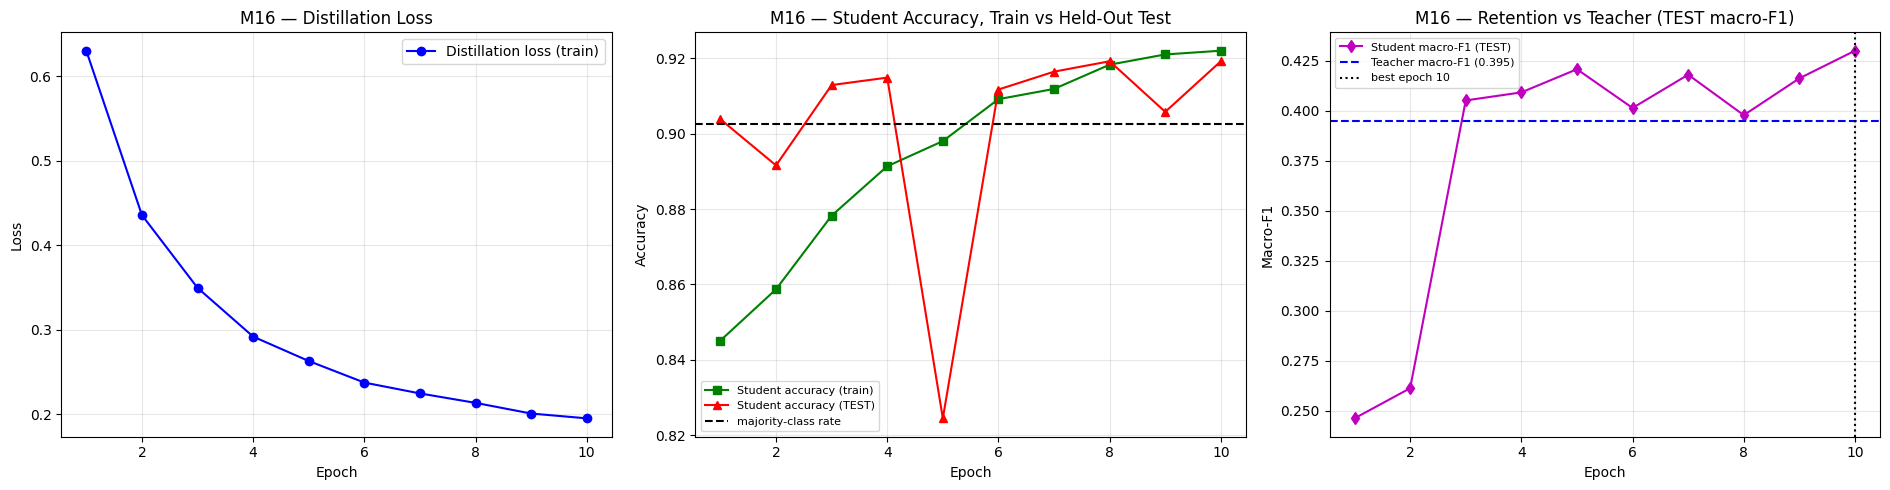

Saved: /kaggle/working/results_M16/Distillation_Loss_Curve.png


In [9]:
# ============================================================
# Section 6: Loss & Retention Curves
# ============================================================

epochs_x = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(epochs_x, history['loss'], 'b-o', label='Distillation loss (train)')
axes[0].set_title('M16 — Distillation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(epochs_x, history['train_accuracy'], 'g-s', label='Student accuracy (train)')
axes[1].plot(epochs_x, history['test_accuracy'], 'r-^', label='Student accuracy (TEST)')
axes[1].axhline(teacher_metrics['majority_class_rate'], color='k', ls='--',
                label='majority-class rate')
axes[1].set_title('M16 — Student Accuracy, Train vs Held-Out Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=8)

axes[2].plot(epochs_x, history['test_f1_macro'], 'm-d', label='Student macro-F1 (TEST)')
axes[2].axhline(teacher_metrics['f1_macro'], color='b', ls='--',
                label=f'Teacher macro-F1 ({teacher_metrics["f1_macro"]:.3f})')
axes[2].axvline(best['epoch'], color='k', ls=':', label=f'best epoch {best["epoch"]}')
axes[2].set_title('M16 — Retention vs Teacher (TEST macro-F1)')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Macro-F1')
axes[2].grid(True, alpha=0.3); axes[2].legend(fontsize=8)

plt.tight_layout()
plot_path = os.path.join(CFG['results_dir'], 'Distillation_Loss_Curve.png')
plt.savefig(plot_path, dpi=300)
plt.savefig(os.path.join(BASE_DIR, 'Distillation_Loss_Curve.png'), dpi=300)
plt.show()
print(f'Saved: {plot_path}')

In [10]:
# ============================================================
# Section 7: Protocol §4 Results JSON Export
# ============================================================

bm = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in best['metrics'].items()}
tm = {k: (round(v, 4) if isinstance(v, float) else v) for k, v in teacher_metrics.items()}

results = {
    'meta': {
        'model_id': 'M16',
        'model_name': 'Teacher-Student Knowledge Distillation',
        'member': 'B',
        'member_name': 'Member B (Disease Diagnosis & OWL)',
        'date_completed': datetime.datetime.now().strftime('%Y-%m-%d'),
        'is_augmented': False,
        'augmentation_method': 'none',
        'notes': (
            'Knowledge distillation to a lightweight 2D-CNN student. Re-run 2026-08-29 per '
            'SYNTHETIC_DATA_REMEDIATION.md item 4. The previous result distilled over 851 '
            'whole recordings and reported last-epoch accuracy on those same rows -- no '
            'train/test split existed in the notebook -- and loaded the teacher with '
            'strict=False inside a try/except that only printed a note, so the teacher could '
            'have been randomly initialised. This run is cycle-level on the corrected '
            'patient-independent official split, the teacher must load fully or the notebook '
            'raises, and the student is scored on TEST only.'
        ),
        'supersedes_note': 'Replaces the 2026-08-05 result (student_accuracy 0.9318, 851 '
                           'recording rows, no split, unchecked teacher load).',
    },
    'config': {k: v for k, v in CFG.items() if not callable(v) and not isinstance(v, np.ndarray)},
    'environment': {
        'platform': PLATFORM,
        'gpu_name': GPU_NAME,
        'pytorch_version': torch.__version__,
        'python_version': sys.version.split()[0],
    },
    'efficiency': {
        'teacher_params': int(teacher_params),
        'student_params': int(student_params),
        'total_params': int(student_params),
        'compression_ratio': round(float(compression_ratio), 2),
        'model_size_mb': round(os.path.getsize(ckpt_path) / (1024 * 1024), 2),
        'gpu_name': GPU_NAME,
    },
    'dataset_info': {
        'dataset': 'ICBHI_2017',
        'data_source': 'real_audio',
        'unit': 'respiratory_cycle',
        'split_method': CFG['split_method'],
        'split_file': SPLIT_FILE,
        'split_file_verified': True,
        'diagnosis_file': DIAG_FILE,
        'official_overlap_patients': sorted(OFFICIAL_OVERLAP),
        'official_overlap_policy': 'reassign_to_train',
        'disease_classes': CFG['disease_classes'],
        'train_samples': int(len(df_train)),
        'test_samples': int(len(df_test)),
        'train_patients': int(df_train.patient_id.nunique()),
        'test_patients': int(df_test.patient_id.nunique()),
        'patient_leakage_verified': True,
        'evaluation_level': 'cycle',
    },
    'best_metrics': {
        'selection_criterion': 'macro_f1 on TEST (accuracy rewards majority-class collapse here)',
        'student_accuracy': bm['accuracy'],
        'student_f1_macro': bm['f1_macro'],
        'majority_class_rate': bm['majority_class_rate'],
        'beats_majority_class': bool(bm['accuracy'] > bm['majority_class_rate']),
        'teacher_accuracy': tm['accuracy'],
        'teacher_f1_macro': tm['f1_macro'],
        'f1_retention_vs_teacher': round(float(retention), 4),
        'compression_ratio': round(float(compression_ratio), 2),
        'final_distill_loss': round(float(history['loss'][-1]), 4),
        **{k: v for k, v in bm.items() if k in
           ('accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'specificity_macro',
            'per_class', 'confusion_matrix_raw', 'confusion_matrix_normalized')},
    },
    'best_epoch': int(best['epoch']),
    'ablation': {
        'ablation_group': 'model_compression',
        'ablation_role': 'student_distillation',
        'baseline_model_id': 'M17',
        'variable_changed': 'knowledge_distillation',
        'variables_held_constant': ['teacher: M17 checkpoint', 'temperature: 3.0', 'seed: 42',
                                    f"split: {CFG['split_method']}"],
        'component_flags': {
            'has_sound_event_head': False,
            'has_disease_head': True,
            'has_distillation': True,
            'owl_stage': 2,
        },
        'loss_weights': {'alpha_distill': CFG['alpha'], 'temperature': CFG['temperature']},
    },
    'training_history': {
        'epochs': list(range(1, len(history['loss']) + 1)),
        **{k: [round(float(x), 6) for x in v] for k, v in history.items()},
    },
}

for out_dir in sorted({CFG['results_dir'], BASE_DIR}):
    os.makedirs(out_dir, exist_ok=True)
    rpath = os.path.join(out_dir, 'results_M16.json')
    with open(rpath, 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print(f'Saved: {rpath}')

# The loose M16_metrics.json is deliberately NOT written any more
# (SYNTHETIC_DATA_REMEDIATION.md item 1). results_M16.json is the only export.
legacy = os.path.join(CFG['results_dir'], 'M16_metrics.json')
if os.path.exists(legacy):
    os.remove(legacy)
    print(f'Removed superseded loose export: {legacy}')

Saved: /kaggle/working/results_M16.json
Saved: /kaggle/working/results_M16/results_M16.json


In [11]:
# ============================================================
# Section 8: Download Results Zip Bundle
# ============================================================
import zipfile
from IPython.display import HTML, display, FileLink

zip_filename = 'M16_results_bundle.zip'
zip_path = os.path.join(BASE_DIR, zip_filename)
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(CFG['results_dir']):
        for f in files:
            fp = os.path.join(root, f)
            arcname = os.path.relpath(fp, BASE_DIR)
            zipf.write(fp, arcname)

print(f"\n{'='*60}")
print('M16 RESULTS DOWNLOAD BUNDLE')
print(f"{'='*60}")
print(f'Zip: {zip_path} ({os.path.getsize(zip_path)/(1024*1024):.2f} MB)')
display(FileLink(zip_filename))



M16 RESULTS DOWNLOAD BUNDLE
Zip: /kaggle/working/M16_results_bundle.zip (1.76 MB)


/kaggle/working/M16_results_bundle.zip